# Cloud filter evaluation on time series

Quantify how three S2 cloud-filter strategies affect the **quality** and **temporal consistency** of CROMA optical embeddings for change detection.

Filters compared:
- **v1 — QA60 + SCL**
- **v2 — Cloud Score+ no dilation**
- **v3 — Cloud Score+ dilated**

Approach: instead of one image per window, extract embeddings for **all** S2 acquisitions in `bef`, `evt`, `aft`. Within-window pairwise similarity gives a noise floor; inter-window similarity gives the change signal; their ratio yields a Signal-to-Noise score per filter.

All metrics are computed **inside the labeled polygon** (CROMA processes the full 120×120 tile, but we evaluate only the patches that fall inside the ground-truth disturbance area).

In [1]:
import os
import glob
import random
import numpy as np
import pandas as pd
import geopandas as gpd
import torch
import rasterio
import rasterio.features
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MplPolygon
from pathlib import Path
from torchgeo.models import croma_base, CROMABase_Weights

# ── Configuration ──
SCRIPT_DIR = os.path.dirname(os.path.abspath("__file__"))

if os.path.exists(os.path.expanduser("~/thesis_tiles_120px")):
    TILES_DIR = os.path.expanduser("~/thesis_tiles_120px")
    SHP_DIR = os.path.join(SCRIPT_DIR, "data_shp")
    DATA_DIR = os.path.join(SCRIPT_DIR, "data_csv")
else:
    TILES_DIR = "/Users/angelicamariamorenorojas/Desktop/Master/thesis/tiles_120px"
    SHP_DIR = os.path.join(SCRIPT_DIR, "data_shp")
    DATA_DIR = os.path.join(SCRIPT_DIR, "data_csv")

# CROMA config
PATCH_SIZE = 8                           # 8x8 px patches
EMBED_DIM = 768                          # ViT-B embedding dim
TILE_SIZE = 120                          # native CROMA tile size (multiple of 8)
GRID_SIZE = TILE_SIZE // PATCH_SIZE      # 15x15 tokens
CROMA_S2_BAND_INDICES = list(range(12))  # 12 bands (CROMA expects this)

device = torch.device("cuda" if torch.cuda.is_available()
                      else "mps" if torch.backends.mps.is_available()
                      else "cpu")

print(f"Device:    {device}")
print(f"TILES_DIR: {TILES_DIR}")
print(f"DATA_DIR:  {DATA_DIR}")
print(f"CROMA grid: {GRID_SIZE}x{GRID_SIZE} tokens, {EMBED_DIM}-D each (patch = 80m x 80m)")

Device:    cuda
TILES_DIR: /share/home/e2406749/thesis_tiles_120px
DATA_DIR:  /share/castor/home/e2406749/tropical_forest_disturbance/data_csv
CROMA grid: 15x15 tokens, 768-D each (patch = 80m x 80m)


## 1. Helpers

Tile loading, CROMA-style normalization, CSV → image_id lookup, disk lookup, polygon mask on the patch grid, CROMA model + encoder hook, and the cosine change map. Reused as-is from the prior notebooks (already validated).

In [2]:
def normalize(x):
    """Per-channel robust normalization to [0, 1] (CROMA pretraining recipe)."""
    x = x.float()                                                # cast tensor to float32 (needed for mean/std)
    imgs = []                                                    # bucket where each normalized channel will go
    for ch in range(x.shape[1]):                                 # loop over the C channel dimension (e.g. 12 S2 bands)
        channel = x[:, ch, :, :]                                 # extract one band -> shape (B, H, W)
        mn = channel.mean() - 2 * channel.std()                  # lower bound: 2 stdev below the channel mean
        mx = channel.mean() + 2 * channel.std()                  # upper bound: 2 stdev above the channel mean
        img = torch.clamp((channel - mn) / (mx - mn + 1e-10), 0, 1)  # rescale into [0,1]; 1e-10 prevents div-by-zero on flat channels
        imgs.append(img.unsqueeze(1))                            # add the channel dim back -> (B, 1, H, W) and store
    return torch.cat(imgs, dim=1)                                # concat all normalized channels back -> (B, C, H, W)


def load_tile(tif_path, band_indices=None):
    with rasterio.open(tif_path) as src:                         # open the GeoTIFF for reading
        data = src.read().astype(np.float32)                     # read all bands -> array (n_bands, H, W) as float32
        transform = src.transform                                # affine transform: pixel (col,row) -> CRS (x,y)
        crs = src.crs                                            # coordinate reference system (e.g. UTM zone)
    if band_indices is not None:                                 # if caller asked for a subset of bands
        data = data[band_indices]                                # reorder/slice the bands accordingly
    return data, transform, crs                                  # return the array plus georeferencing info


def get_image_ids(scenario_df, fid, window):
    """All S2 image_ids in CSV for (fid, window). Empty list if missing/NaN."""
    col = f"{window}IdsS2"                                       # CSV column name, e.g. "evtIdsS2"
    row = scenario_df[scenario_df["fid"].astype(int) == int(fid)]  # find the row(s) for this FID
    if row.empty:                                                # FID not present in this CSV
        return []                                                # nothing to return
    val = row[col].iloc[0]                                       # grab the cell value (comma-separated string or NaN)
    if pd.isna(val) or not isinstance(val, str) or not val.strip():  # missing / NaN / empty string
        return []                                                # treat as no acquisitions
    return [s.strip() for s in val.split(",") if s.strip()]      # split on commas, trim whitespace, drop empties


def find_tile_for_image(fid, product, window, image_id, tile_idx=0):
    p = os.path.join(TILES_DIR, product, f"fid_{fid}", window, image_id, f"tile_{tile_idx}.tif")  # build expected path on disk
    return p if os.path.exists(p) else None                      # return the path if file exists, else None


def polygon_mask_on_grid(fid, transform, crs, grid_size=GRID_SIZE, patch_size=PATCH_SIZE):
    """Rasterize polygon onto the (grid_size, grid_size) patch grid (cell = 80 m x 80 m)."""
    poly_row = gdf[gdf["fid"] == str(fid)]                       # locate this polygon in the GeoDataFrame
    if poly_row.empty:                                           # no polygon found for this FID
        return np.zeros((grid_size, grid_size), dtype=bool)      # return an all-False mask of correct shape
    poly_reproj = poly_row.to_crs(crs)                           # reproject polygon to the tile's CRS so coords align
    px = transform.a * patch_size                                # patch width in CRS units (10 m/px * 8 px = 80 m)
    py = -transform.e * patch_size                               # patch height in CRS units (negative because y axis flips)
    patch_transform = rasterio.transform.from_origin(transform.c, transform.f, px, py)  # transform at patch resolution (80 m/cell)
    geoms = [(g, 1) for g in poly_reproj.geometry if not g.is_empty]  # (geometry, burn-value) pairs for rasterize
    mask = rasterio.features.rasterize(                          # turn vector polygon into raster grid
        geoms, out_shape=(grid_size, grid_size),                 # output shape = 15 x 15
        transform=patch_transform, fill=0, all_touched=True, dtype="uint8"  # all_touched: any cell that touches polygon -> 1
    ).astype(bool)                                               # convert 0/1 ints to False/True
    return mask                                                  # final boolean mask: True = patch is inside polygon


def load_croma_model(modalities):
    model = croma_base(weights=CROMABase_Weights.CROMA_VIT,      # build CROMA-Base ViT and load pretrained weights
                       modalities=modalities, image_size=TILE_SIZE)  # which encoders to instantiate, and tile size (120)
    return model.to(device).eval()                               # move to GPU and switch to eval mode (no dropout, frozen norm stats)


def encode_tile(model, tile_data, modality):
    """Run CROMA on a 120x120 tile, return (15, 15, 768) patch tokens."""
    x = torch.from_numpy(tile_data).unsqueeze(0)                 # numpy -> torch tensor, add batch dim -> (1, C, 120, 120)
    x = normalize(x).to(device)                                  # apply CROMA-style normalization, move to GPU
    captured = {}                                                # empty dict that the hook will fill with the encoder output
    encoder = model.s2_encoder if modality == "optical" else model.s1_encoder  # pick which encoder (ViT) to attach the hook to

    def hook(module, inp, out):                                  # PyTorch calls this with the encoder's output automatically
        captured["tokens"] = out                                 # save it for retrieval after the forward pass

    h = encoder.register_forward_hook(hook)                      # attach the hook; returns a handle for later removal
    with torch.no_grad():                                        # disable gradient tracking (faster, less memory)
        if modality == "optical":                                # optical branch
            _ = model(x_optical=x)                               # full forward pass; final output ignored, hook captured what we need
        else:                                                    # SAR branch
            _ = model(x_sar=x)                                   # same idea for SAR
    h.remove()                                                   # detach the hook so it doesn't fire on later forward passes

    out = captured["tokens"]                                     # pull the encoder output we saved
    if isinstance(out, tuple):                                   # some torchgeo versions return (tokens, extras)
        out = out[0]                                             # keep only the tokens
    tokens = out.cpu().numpy().squeeze()                         # GPU -> CPU -> numpy; squeeze drops batch dim -> (N, 768)
    expected = GRID_SIZE * GRID_SIZE                             # 15 * 15 = 225 patch tokens expected
    if tokens.shape[0] == expected + 1:                          # 226 means there's an extra [CLS] token at index 0
        tokens = tokens[1:]                                      # drop the CLS, keep only the 225 spatial patch tokens
    return tokens.reshape(GRID_SIZE, GRID_SIZE, EMBED_DIM)       # reshape flat sequence back to spatial grid (15, 15, 768)


def cosine_change_map(tokens_a, tokens_b):
    """Per-patch (1 - cosine_similarity) between two (15,15,768) token grids."""
    h, w = tokens_a.shape[:2]                                    # grid spatial dims (typically 15, 15)
    a = tokens_a.reshape(-1, EMBED_DIM)                          # flatten grid -> (225, 768) row per patch
    b = tokens_b.reshape(-1, EMBED_DIM)                          # same for second tile
    a_n = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-10) # L2-normalize each row -> unit vectors (kills magnitude)
    b_n = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-10) # same for b
    sim = (a_n * b_n).sum(axis=1).reshape(h, w)                  # row-wise dot product = cosine similarity, reshape -> (15, 15)
    return 1.0 - sim                                             # convert similarity to change: 0 = identical, ~1 = very different

## 2. Load CSVs, polygons, and find divergent FIDs

Each filter version has its own CSV. We also load the labeled polygons (ground-truth disturbance areas) and identify FIDs where:
1. The three filters picked **different** acquisitions in at least one window.
2. `tile_0` is on disk for every (version × window) so the comparison is runnable.

We include `evt`, `bef`, AND `aft` because the time-series analysis covers all three windows.

In [3]:
scenarios = {
    "v1": pd.read_csv(os.path.join(DATA_DIR, "v1_images_s2_s1.csv")),
    "v2": pd.read_csv(os.path.join(DATA_DIR, "v2_images_s2_s1.csv")),
    "v3": pd.read_csv(os.path.join(DATA_DIR, "v3_images_s2_s1.csv")),
}
scenario_labels = {
    "v1": "QA60+SCL",
    "v2": "CS+ no dilation",
    "v3": "CS+ dilated",
}

shp_path = os.path.join(SHP_DIR, "label_polygons.shp")
gdf = gpd.read_file(shp_path)
gdf["fid"] = gdf["fid"].astype(int).astype(str)


def fids_with_divergent_versions(scenarios, windows=("evt", "bef", "aft"), check_disk=True):
    """FIDs where first(image_id) differs across versions for at least one window
    AND tile_0 exists on disk for every (version, window). Uses image_id[0] only
    for divergence detection — the time-series extraction will use all of them."""
    all_fids = sorted({int(f) for df in scenarios.values() for f in df["fid"]})
    out = []
    for fid in all_fids:
        per_version = {}
        runnable = True
        for v, df in scenarios.items():
            entry = {}
            for w in windows:
                ids = get_image_ids(df, fid, w)
                if not ids:
                    entry[w] = None
                    runnable = False
                    continue
                image_id = ids[0]
                if check_disk and find_tile_for_image(fid, "s2_l2a", w, image_id) is None:
                    runnable = False
                entry[w] = image_id
            per_version[v] = entry
        if check_disk and not runnable:
            continue
        differ_in = [w for w in windows
                     if len({per_version[v][w] for v in per_version
                             if per_version[v][w] is not None}) > 1]
        if differ_in:
            out.append({"fid": fid, "per_version": per_version, "differ_in": differ_in})
    return out


divergent = fids_with_divergent_versions(scenarios, windows=("evt", "bef", "aft"), check_disk=True)
print(f"Polygons loaded: {len(gdf)}")
print(f"Scenarios:       {list(scenarios.keys())}")
print(f"Divergent FIDs (with all tiles on disk for evt/bef/aft): {len(divergent)}")
if divergent:
    print(f"  First 10: {[e['fid'] for e in divergent[:10]]}")

Polygons loaded: 389
Scenarios:       ['v1', 'v2', 'v3']
Divergent FIDs (with all tiles on disk for evt/bef/aft): 8
  First 10: [71, 101, 165, 240, 281, 315, 364, 387]


## 3. Step 1 — List image_ids per (version, window) for a random divergent FID

For one randomly-selected divergent FID, list **all** S2 image_ids in each window (`bef`, `evt`, `aft`) for the **three** filter versions. This is the input list that the time-series extraction (next step) will feed into CROMA.

The seed is fixed so re-running the notebook always picks the same FID. To explore a different one, change the `random.seed(...)` line.

In [4]:
random.seed(7)
TEST_FID = random.choice(divergent)["fid"] if divergent else None
print(f"TEST_FID = {TEST_FID}\n")

image_ids_by_version_window = {}
if TEST_FID is None:
    print("No divergent FIDs available.")
else:
    for v, df in scenarios.items():
        image_ids_by_version_window[v] = {}
        print(f"── {v} ({scenario_labels[v]}) ──")
        for window in ("bef", "evt", "aft"):
            ids = get_image_ids(df, TEST_FID, window)
            image_ids_by_version_window[v][window] = ids
            print(f"  {window}: {len(ids)} image(s)")
            for image_id in ids:
                print(f"      {image_id}")
        print()

    # Quick summary across versions: total acquisitions per window
    print("Total acquisitions per window (across versions):")
    for window in ("bef", "evt", "aft"):
        counts = {v: len(image_ids_by_version_window[v][window]) for v in scenarios}
        print(f"  {window}: {counts}")

TEST_FID = 315

── v1 (QA60+SCL) ──
  bef: 13 image(s)
      20230714T142721_20230714T142941_T20LNR
      20230709T142719_20230709T142938_T20LNR
      20230704T142721_20230704T142729_T20LNR
      20230629T142719_20230629T143340_T20LNR
      20230624T142721_20230624T142715_T20LNR
      20230619T142719_20230619T142934_T20LNR
      20230609T142719_20230609T142938_T20LNR
      20230604T142721_20230604T142716_T20LNR
      20230525T142721_20230525T142853_T20LNR
      20230520T142719_20230520T142902_T20LNR
      20230515T142711_20230515T142713_T20LNR
      20230430T142719_20230430T142714_T20LNR
      20230214T142711_20230214T143425_T20LNR
  evt: 3 image(s)
      20230719T142719_20230719T142939_T20LNR
      20230724T142721_20230724T142717_T20LNR
      20230729T142719_20230729T142718_T20LNR
  aft: 2 image(s)
      20230808T142719_20230808T143119_T20LNR
      20230818T142719_20230818T143227_T20LNR

── v2 (CS+ no dilation) ──
  bef: 11 image(s)
      20230714T142721_20230714T142941_T20LNR
      2

## 4. Step 2 — Verify tiles exist on disk

For every `(version, window, image_id)` from Paso 1, check whether `tile_0.tif` exists at the expected path under `TILES_DIR`. The tile pipeline (run separately, earlier) processes CSV image_ids into tiles, but it may not produce a tile for every image_id (batch limits, processing errors, etc.) — so the CSV is a superset of what is actually on disk.

This step **does not download anything**. It only verifies presence. The divergence filter from section 2 only required `tile_0.tif` for the **first** image_id of each window, so additional acquisitions in the time series may or may not be on disk.

The result is stored in `available_tiles` — a dict that Paso 3 (extraction) will iterate over. Image_ids without a tile on disk are silently dropped from the time series for this FID.

In [5]:
print(f"Checking tile_0.tif on disk for FID {TEST_FID}\n")

available_tiles = {}                                             # {version: {window: [(image_id, path), ...]}}

for v in scenarios:                                              # iterate over v1, v2, v3
    available_tiles[v] = {}                                      # init nested dict for this version
    print(f"── {v} ({scenario_labels[v]}) ──")
    for window in ("bef", "evt", "aft"):                         # check each window
        ids = image_ids_by_version_window[v][window]             # list of image_ids from Paso 1
        available_tiles[v][window] = []                          # bucket for surviving (image_id, path) pairs
        if not ids:                                              # no image_ids in CSV for this window
            print(f"  {window}  --       (no image_ids in CSV)")
            continue
        for image_id in ids:                                     # check every acquisition listed in CSV
            path = find_tile_for_image(TEST_FID, "s2_l2a", window, image_id)  # returns path if file exists, else None
            status = "OK     " if path else "MISSING"            # human-readable status flag
            print(f"  {window}  [{status}]  {image_id}")
            if path:                                             # keep only acquisitions whose tile_0.tif is on disk
                available_tiles[v][window].append((image_id, path))
    print()

# Summary count table: on-disk / total per (version, window)
print("Summary (on-disk / total per window):")
header = f"{'window':<6}" + "".join(f"{v + ' (' + scenario_labels[v] + ')':>26}" for v in scenarios)
print(header)
print("-" * len(header))
for window in ("bef", "evt", "aft"):
    counts = [f"{len(available_tiles[v][window])}/{len(image_ids_by_version_window[v][window])}" for v in scenarios]
    print(f"{window:<6}" + "".join(f"{c:>26}" for c in counts))

# Quick sanity check: do we have enough material for the metrics?
print("\nMinimum requirements for the time-series metrics:")
for v in scenarios:
    n_bef = len(available_tiles[v]["bef"])
    n_evt = len(available_tiles[v]["evt"])
    can_consistency = n_bef >= 2                                 # need >=2 bef acquisitions for within-window cos_sim
    can_change = n_bef >= 1 and n_evt >= 1                       # need at least one of each for change signal
    print(f"  {v}: bef={n_bef}, evt={n_evt}  -> "
          f"consistency={'YES' if can_consistency else 'NO'}, "
          f"change_signal={'YES' if can_change else 'NO'}")

Checking tile_0.tif on disk for FID 315

── v1 (QA60+SCL) ──
  bef  [OK     ]  20230714T142721_20230714T142941_T20LNR
  bef  [OK     ]  20230709T142719_20230709T142938_T20LNR
  bef  [OK     ]  20230704T142721_20230704T142729_T20LNR
  bef  [OK     ]  20230629T142719_20230629T143340_T20LNR
  bef  [OK     ]  20230624T142721_20230624T142715_T20LNR
  bef  [OK     ]  20230619T142719_20230619T142934_T20LNR
  bef  [OK     ]  20230609T142719_20230609T142938_T20LNR
  bef  [OK     ]  20230604T142721_20230604T142716_T20LNR
  bef  [OK     ]  20230525T142721_20230525T142853_T20LNR
  bef  [OK     ]  20230520T142719_20230520T142902_T20LNR
  bef  [OK     ]  20230515T142711_20230515T142713_T20LNR
  bef  [OK     ]  20230430T142719_20230430T142714_T20LNR
  bef  [OK     ]  20230214T142711_20230214T143425_T20LNR
  evt  [OK     ]  20230719T142719_20230719T142939_T20LNR
  evt  [OK     ]  20230724T142721_20230724T142717_T20LNR
  evt  [OK     ]  20230729T142719_20230729T142718_T20LNR
  aft  [OK     ]  20230808T

## 5. Step 3 — Time-series extraction with CROMA

For every `(version, window, image_id)` in `available_tiles`, load the tile, run CROMA's optical encoder, and store the `(15, 15, 768)` patch tokens in a nested dict:

```
embeddings[version][window][image_id] = tokens   # shape (15, 15, 768)
```

CROMA processes the **whole 120×120 tile**; the polygon mask is applied later (Paso 4 onwards) to select patches inside the labeled disturbance area.

The model is loaded **once** before the loop and freed at the end to release GPU memory.

In [6]:
import time                                                       # for timing the extraction loop

# Count how many CROMA forward passes we will do
total_tiles = sum(len(available_tiles[v][w])                     # sum across all (version, window) buckets
                  for v in scenarios for w in ("bef", "evt", "aft"))
print(f"Total tiles to process: {total_tiles}\n")

print("Loading CROMA optical model (once)...")
model_opt = load_croma_model(['optical'])                        # ViT-B optical encoder, on GPU, eval mode
print("Model ready.\n")

# Nested dict: embeddings[version][window][image_id] = (15, 15, 768)
embeddings = {v: {w: {} for w in ("bef", "evt", "aft")} for v in scenarios}

start = time.time()
done = 0

for v in scenarios:                                              # iterate v1, v2, v3
    for window in ("bef", "evt", "aft"):                         # iterate windows
        for image_id, path in available_tiles[v][window]:        # iterate runnable acquisitions
            data, _, _ = load_tile(path, band_indices=CROMA_S2_BAND_INDICES)  # load (12, 120, 120) array
            tokens = encode_tile(model_opt, data, "optical")     # CROMA -> (15, 15, 768)
            embeddings[v][window][image_id] = tokens             # store in the nested dict
            done += 1
            print(f"  [{done:>3}/{total_tiles}] {v} {window:<3}  "
                  f"shape={tokens.shape}  mean={tokens.mean():+.3f}  std={tokens.std():.3f}")

# Free GPU memory now that we're done with CROMA for this FID
del model_opt
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"\nFinished in {time.time() - start:.1f}s")

# Verify nested counts (should match available_tiles)
print("\nNested counts (embeddings stored / available tiles):")
for v in scenarios:
    for window in ("bef", "evt", "aft"):
        n_emb = len(embeddings[v][window])
        n_avail = len(available_tiles[v][window])
        print(f"  embeddings[{v}][{window}]: {n_emb}/{n_avail}")

# Sanity check: pick the first stored embedding and inspect a few values
print("\nSanity check on the first stored embedding:")
for v in scenarios:
    for window in ("bef", "evt", "aft"):
        if embeddings[v][window]:                                # first non-empty bucket
            image_id = next(iter(embeddings[v][window]))         # first key
            t = embeddings[v][window][image_id]
            print(f"  {v}/{window}/{image_id[:25]}…  shape={t.shape}  "
                  f"first 5 values of patch (0,0): {t[0, 0, :5]}")
            break
    else:
        continue
    break

Total tiles to process: 49

Loading CROMA optical model (once)...
Model ready.

  [  1/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.973
  [  2/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.973
  [  3/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.972
  [  4/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.972
  [  5/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.973
  [  6/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.973
  [  7/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.972
  [  8/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.973
  [  9/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.972
  [ 10/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.972
  [ 11/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.973
  [ 12/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.972
  [ 13/49] v1 bef  shape=(15, 15, 768)  mean=-0.000  std=0.973
  [ 14/49] v1 evt  shape=(15, 15, 768)  mean=-0.000  std=0.973
  [ 15/49] v1 evt  shape=(15, 15, 768)

## 6. Step 4 — Build polygon mask on the 15×15 patch grid

Rasterize the labeled disturbance polygon onto the patch grid. Each cell of the 15×15 grid corresponds to one CROMA patch (80 m × 80 m on the ground). Cells that overlap the polygon get `True`; the rest get `False`.

All tiles for the same FID share the same `transform` and `crs` (the tile pipeline cuts at the same geographic location every time), so we can grab them from any one of the loaded tiles.

The mask is the **same for all (version, window)** since the polygon is a property of the FID, not of the cloud filter.

FID 315 — polygon mask on 15x15 patch grid:
  patches inside polygon:  32
  patches outside polygon: 193
  total patches:           225


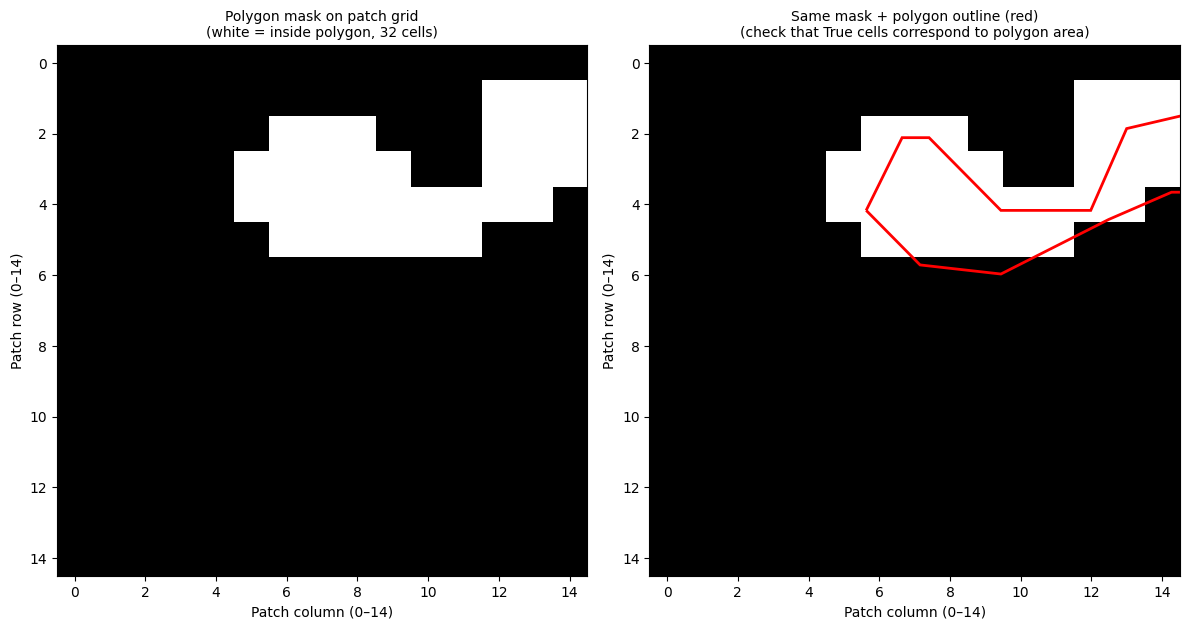

In [7]:
# Find the first tile path on disk to grab a transform+CRS for the polygon mask.
first_tile_path = None                                           # placeholder
for v in scenarios:                                              # iterate v1, v2, v3
    for window in ("bef", "evt", "aft"):                         # iterate windows
        if available_tiles[v][window]:                           # any acquisition with tile on disk
            first_tile_path = available_tiles[v][window][0][1]   # take its file path
            break
    if first_tile_path:
        break
assert first_tile_path is not None, "No tiles available — cannot build mask"

# Load just the metadata of that tile (we don't actually need the pixel data again).
_, transform, crs = load_tile(first_tile_path, band_indices=CROMA_S2_BAND_INDICES)

# Rasterize the polygon onto the 15x15 patch grid.
mask = polygon_mask_on_grid(TEST_FID, transform, crs)            # bool array, shape (15, 15)
n_in = int(mask.sum())                                           # count of True cells
n_total = mask.size                                              # 225

print(f"FID {TEST_FID} — polygon mask on 15x15 patch grid:")
print(f"  patches inside polygon:  {n_in}")
print(f"  patches outside polygon: {n_total - n_in}")
print(f"  total patches:           {n_total}")

# Visualize the mask with the polygon outline overlaid in red.
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Left: the boolean mask itself (white = inside, black = outside)
axes[0].imshow(mask, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
axes[0].set_title(f"Polygon mask on patch grid\n(white = inside polygon, {n_in} cells)", fontsize=10)
axes[0].set_xlabel("Patch column (0–14)")
axes[0].set_ylabel("Patch row (0–14)")

# Right: the mask with the actual polygon outline drawn on top, scaled to patch coords.
axes[1].imshow(mask, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
poly_row = gdf[gdf["fid"] == str(TEST_FID)]                      # locate polygon for this FID
if not poly_row.empty:
    poly_reproj = poly_row.to_crs(crs)                           # reproject to tile CRS
    for geom in poly_reproj.geometry:
        if geom.is_empty:
            continue
        geoms = [geom] if geom.geom_type == "Polygon" else list(geom.geoms)  # handle Multi
        for g in geoms:
            xs, ys = g.exterior.coords.xy                        # polygon vertex coords in CRS units
            pixel_coords = [(~transform * (x, y)) for x, y in zip(xs, ys)]   # CRS -> pixel coords
            patch_coords = [(x / PATCH_SIZE, y / PATCH_SIZE) for x, y in pixel_coords]  # pixel -> patch coords
            axes[1].add_patch(MplPolygon(patch_coords, closed=True,
                                         edgecolor="red", facecolor="none", linewidth=2))
axes[1].set_title("Same mask + polygon outline (red)\n(check that True cells correspond to polygon area)", fontsize=10)
axes[1].set_xlabel("Patch column (0–14)")
axes[1].set_ylabel("Patch row (0–14)")

plt.tight_layout()
plt.show()